In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aiexplorer77/internship-selection-prediction-dataset/Internship_Selection_Dataset.csv


In [2]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [3]:
data = pd.read_csv('/kaggle/input/datasets/aiexplorer77/internship-selection-prediction-dataset/Internship_Selection_Dataset.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [5]:
data.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [6]:
data = data.drop("student_id", axis=1)

In [7]:
data.select_dtypes(include="object").columns

Index(['extracurricular', 'college_tier', 'placement_training'], dtype='object')

In [8]:
le = LabelEncoder()

data['extracurricular'] = le.fit_transform(data['extracurricular']) #yes = 1 oldu artık
data['college_tier'] = le.fit_transform(data['college_tier'])
data['placement_training'] = le.fit_transform(data['placement_training'])

data.head()

,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,6.87,7,0,0,4,3,2,7,1,1,0,7,5,9,3,1,4,4,1,1
1,9.75,4,4,2,3,3,6,1,1,1,3,2,8,8,3,9,8,5,1,1
2,8.66,2,1,1,2,1,4,6,1,1,4,1,5,2,2,1,3,2,1,1
3,7.99,5,4,2,8,8,10,8,0,1,1,5,5,9,2,7,10,1,1,1
4,5.78,3,2,2,4,9,1,7,1,2,4,7,3,8,7,8,6,5,1,1


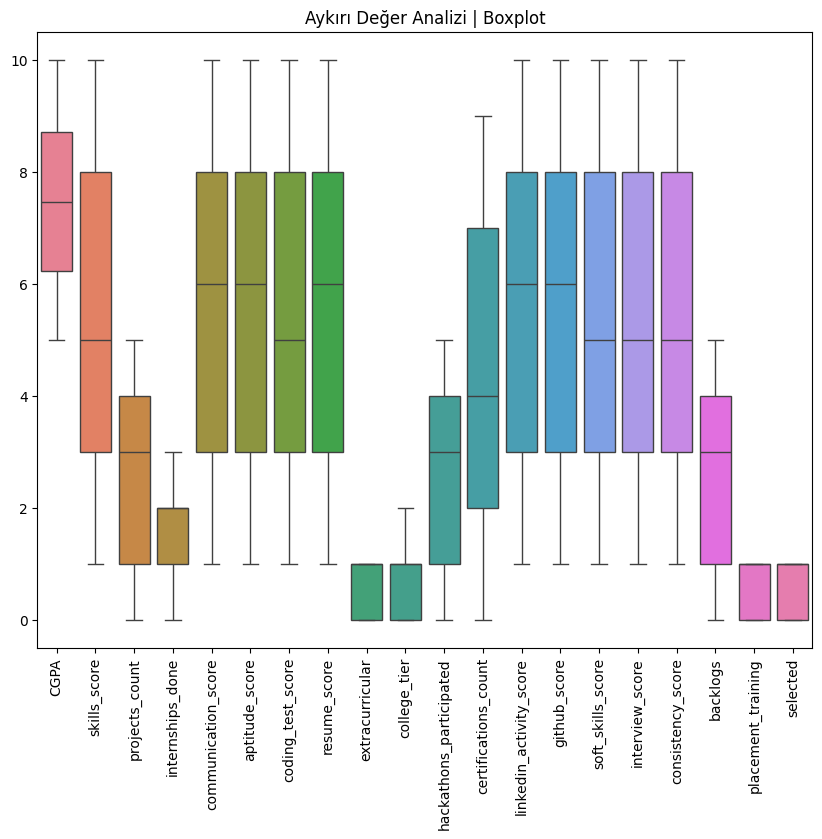

In [9]:
plt.figure(figsize=(10,8))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title("Aykırı Değer Analizi | Boxplot")
plt.show()

In [10]:
X = data.drop("selected", axis=1)
y = data["selected"]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

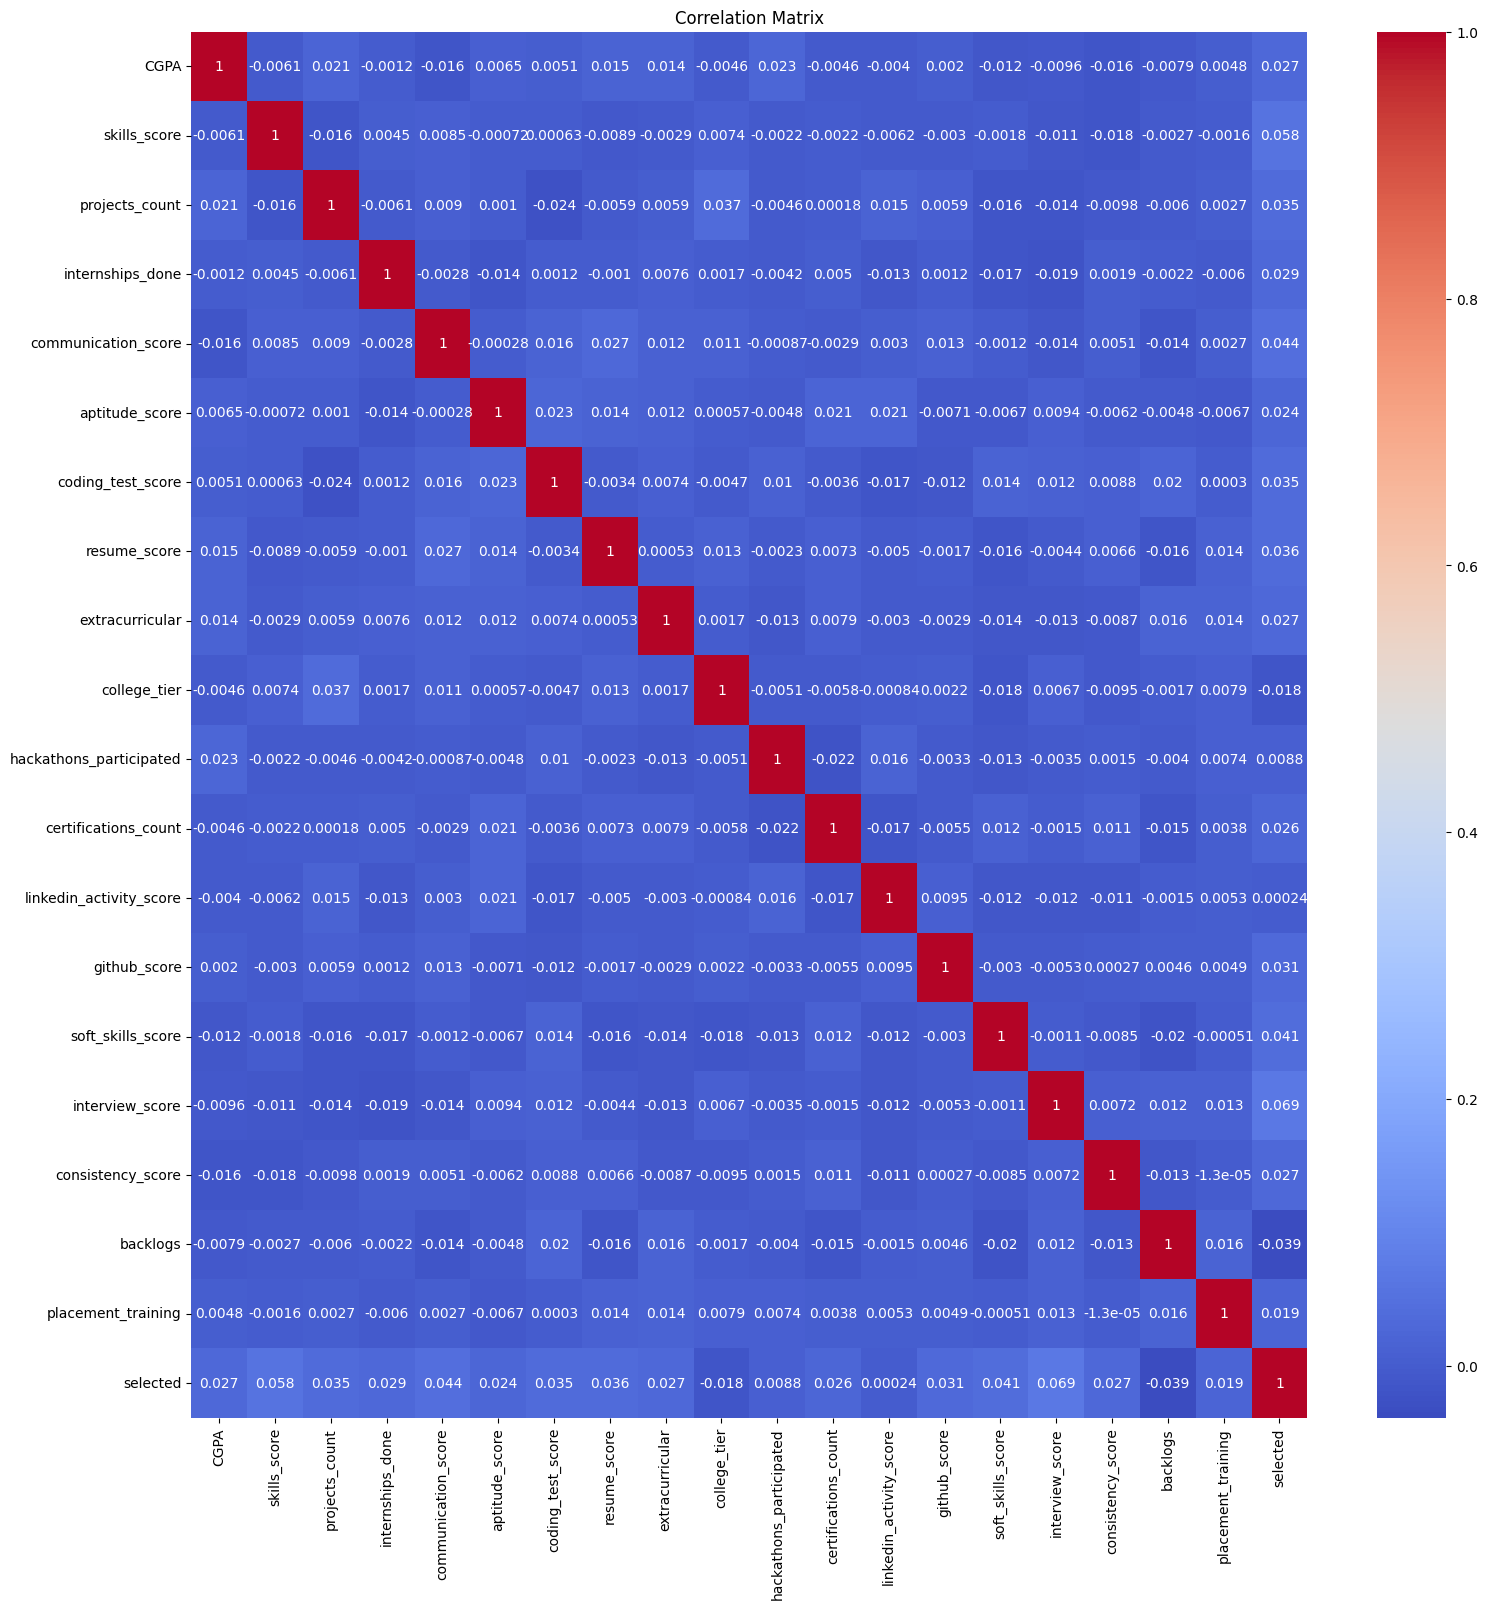

In [12]:
plt.figure(figsize=(18,18))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig(
    "heatmap.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

In [13]:
corr_selected = data.corr()["selected"].sort_values(ascending=False)

In [14]:
corr_selected

selected                   1.000000
interview_score            0.069152
skills_score               0.058453
communication_score        0.044100
soft_skills_score          0.041482
resume_score               0.036477
projects_count             0.035092
coding_test_score          0.035067
github_score               0.031460
internships_done           0.029197
extracurricular            0.027474
consistency_score          0.027301
CGPA                       0.027016
certifications_count       0.025724
aptitude_score             0.024051
placement_training         0.019435
hackathons_participated    0.008805
linkedin_activity_score    0.000236
college_tier              -0.018090
backlogs                  -0.038708
Name: selected, dtype: float64

In [15]:
X_train,X_test,y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

In [16]:
results = []

for k in range(1,  X_train.shape[1]):

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(
        X_train,
        y_train
    )

    X_test_selected = selector.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_selected, y_train)

    preds = knn.predict(X_test_selected)

    acc = accuracy_score(y_test, preds)

    results.append((k, acc))
results_df = pd.DataFrame(results, columns=["k", "Accuracy"])
results_df

,k,Accuracy
0,1,0.6005
1,2,0.6835
2,3,0.6750
3,4,0.6705
4,5,0.6740
5,6,0.6680
6,7,0.6730
7,8,0.6760
8,9,0.6755
9,10,0.6695


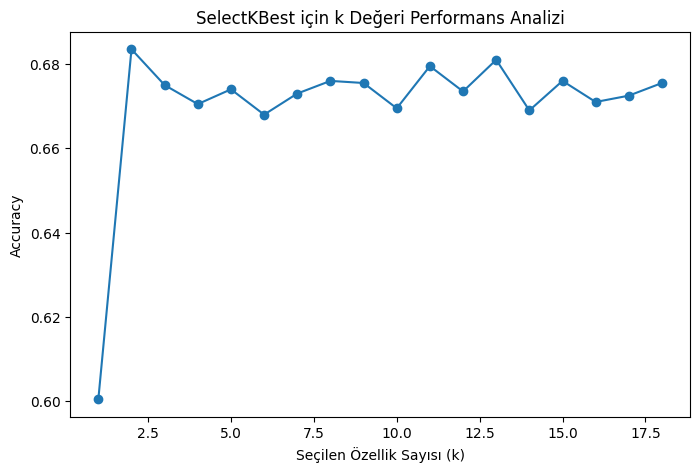

In [17]:
plt.figure(figsize=(8,5))
plt.plot(results_df["k"], results_df["Accuracy"], marker="o")
plt.xlabel("Seçilen Özellik Sayısı (k)")
plt.ylabel("Accuracy")
plt.title("SelectKBest için k Değeri Performans Analizi")
plt.show()

In [18]:
best_k = results_df.loc[
    results_df["Accuracy"].idxmax()
]

best_k

k           2.0000
Accuracy    0.6835
Name: 1, dtype: float64

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
results = []

for k in range(1, X_train.shape[1]):

    selector = SelectKBest(score_func=f_classif, k=k)

    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)

    knn = KNeighborsClassifier()

    knn.fit(X_train_selected, y_train)

    preds = knn.predict(X_test_selected)

    acc = accuracy_score(y_test, preds)

    results.append((k, acc))

results_df = pd.DataFrame(results, columns=["k", "Accuracy"])
results_df

,k,Accuracy
0,1,0.6005
1,2,0.6610
2,3,0.6785
3,4,0.6740
4,5,0.6765
5,6,0.6730
6,7,0.6755
7,8,0.6740
8,9,0.6795
9,10,0.6735


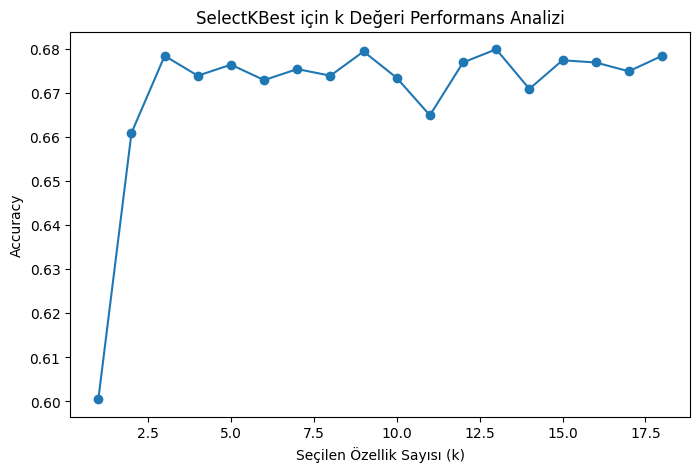

In [21]:
plt.figure(figsize=(8,5))
plt.plot(results_df["k"], results_df["Accuracy"], marker="o")
plt.xlabel("Seçilen Özellik Sayısı (k)")
plt.ylabel("Accuracy")
plt.title("SelectKBest için k Değeri Performans Analizi")
plt.show()

In [22]:
best_k = results_df.loc[
    results_df["Accuracy"].idxmax()
]

best_k

k           13.00
Accuracy     0.68
Name: 12, dtype: float64

In [23]:
selector = SelectKBest(
    score_func=f_classif,
    k=13
)

X_selected = selector.fit_transform(
    X_scaled,
    y
)

In [24]:
selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['CGPA', 'skills_score', 'projects_count', 'internships_done',
       'communication_score', 'coding_test_score', 'resume_score',
       'extracurricular', 'github_score', 'soft_skills_score',
       'interview_score', 'consistency_score', 'backlogs'],
      dtype='object')

In [25]:
scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

scores

,Feature,Score
15,interview_score,48.040152
1,skills_score,34.278262
4,communication_score,19.482271
14,soft_skills_score,17.234034
17,backlogs,15.002732
7,resume_score,13.320653
2,projects_count,12.327476
6,coding_test_score,12.309366
13,github_score,9.904900
3,internships_done,8.529969


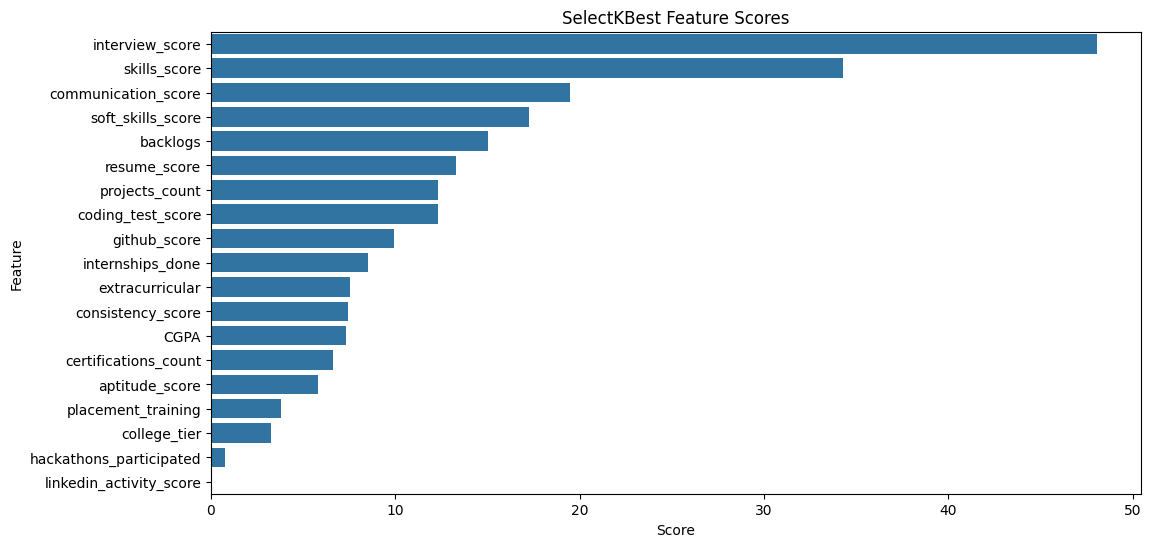

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=scores,
    x="Score",
    y="Feature"
)

plt.title("SelectKBest Feature Scores")

plt.show()

In [27]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [28]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,CGPA,0.132855
16,consistency_score,0.074960
5,aptitude_score,0.068327
12,linkedin_activity_score,0.067700
11,certifications_count,0.066321
13,github_score,0.060981
7,resume_score,0.057838
14,soft_skills_score,0.056773
4,communication_score,0.055852
6,coding_test_score,0.053569


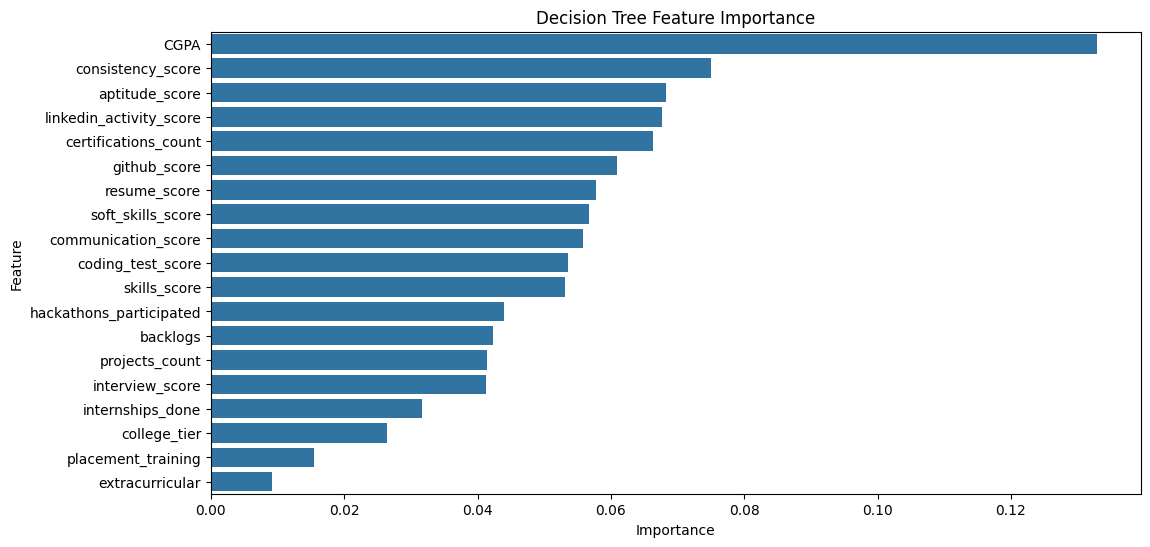

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [30]:
top_tree_features = importance_df.head(13)["Feature"].tolist()

top_tree_features

['CGPA',
 'consistency_score',
 'aptitude_score',
 'linkedin_activity_score',
 'certifications_count',
 'github_score',
 'resume_score',
 'soft_skills_score',
 'communication_score',
 'coding_test_score',
 'skills_score',
 'hackathons_participated',
 'backlogs']

In [31]:
X_all = X
X_select = X[selected_features]
X_tree = X[top_tree_features]

In [32]:
def evaluate_feature_set(X_data, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_scaled, y_train)

    preds = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.4f}")

    return acc

In [33]:
acc_all = evaluate_feature_set(
    X_all,
    "All Features"
)

acc_select = evaluate_feature_set(
    X_select,
    "SelectKBest Features"
)

acc_tree = evaluate_feature_set(
    X_tree,
    "Decision Tree Features"
)

All Features Accuracy: 0.6780
SelectKBest Features Accuracy: 0.6895
Decision Tree Features Accuracy: 0.6765


In [34]:
comparison_df = pd.DataFrame({
    "Feature Set": [
        "All Features",
        "SelectKBest",
        "Decision Tree"
    ],
    "Accuracy": [
        acc_all,
        acc_select,
        acc_tree
    ]
})

comparison_df

,Feature Set,Accuracy
0,All Features,0.6780
1,SelectKBest,0.6895
2,Decision Tree,0.6765


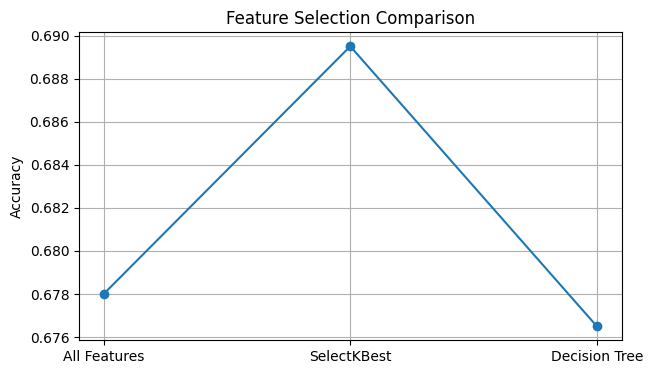

In [35]:
plt.figure(figsize=(7,4))

plt.plot(
    comparison_df["Feature Set"],
    comparison_df["Accuracy"],
    marker="o"
)

plt.title("Feature Selection Comparison")
plt.ylabel("Accuracy")
plt.grid(True)

plt.savefig(
    "feature_selection_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [36]:
X_final = X[selected_features]
X_final.head()

,CGPA,skills_score,projects_count,internships_done,communication_score,coding_test_score,resume_score,extracurricular,github_score,soft_skills_score,interview_score,consistency_score,backlogs
0,6.87,7,0,0,4,2,7,1,9,3,1,4,4
1,9.75,4,4,2,3,6,1,1,8,3,9,8,5
2,8.66,2,1,1,2,4,6,1,2,2,1,3,2
3,7.99,5,4,2,8,10,8,0,9,2,7,10,1
4,5.78,3,2,2,4,1,7,1,8,7,8,6,5


In [37]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_final,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [39]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [40]:
svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [41]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
knn_pred = knn.predict(X_test_scaled)
svm_pred = svm.predict(X_test_scaled)
dt_pred = dt.predict(X_test_scaled)

In [43]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n{name}")

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true, y_pred))

    print("Recall:",
          recall_score(y_true, y_pred))

    print("F1 Score:",
          f1_score(y_true, y_pred))

In [44]:
evaluate_model(
    "KNN",
    y_test,
    knn_pred
)

evaluate_model(
    "SVM",
    y_test,
    svm_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)


KNN
Accuracy: 0.6806666666666666
Precision: 0.7373202119606359
Recall: 0.8806509945750453
F1 Score: 0.8026370004120313

SVM
Accuracy: 0.7373333333333333
Precision: 0.7373333333333333
Recall: 1.0
F1 Score: 0.8488104374520338

Decision Tree
Accuracy: 0.608
Precision: 0.7420560747663552
Recall: 0.7179023508137432
F1 Score: 0.7297794117647058


In [45]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

cm

array([[   0,  394],
       [   0, 1106]])

In [46]:
data["selected"].value_counts()

selected
1    7374
0    2626
Name: count, dtype: int64

In [47]:
cm_knn = confusion_matrix(
    y_test,
    knn_pred
)

cm_knn

array([[ 47, 347],
       [132, 974]])

In [48]:
cm_dt = confusion_matrix(
    y_test,
    dt_pred
)

cm_dt

array([[118, 276],
       [312, 794]])

In [49]:
knn_probs = knn.predict_proba(X_test_scaled)[:,1]

svm_probs = svm.predict_proba(X_test_scaled)[:,1]

dt_probs = dt.predict_proba(X_test_scaled)[:,1]

In [50]:
knn_fpr, knn_tpr, _ = roc_curve(
    y_test,
    knn_probs
)

svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probs
)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_probs
)

In [51]:
knn_auc = auc(knn_fpr, knn_tpr)

svm_auc = auc(svm_fpr, svm_tpr)

dt_auc = auc(dt_fpr, dt_tpr)

print("KNN AUC:", knn_auc)

print("SVM AUC:", svm_auc)

print("Decision Tree AUC:", dt_auc)

KNN AUC: 0.485929310360654
SVM AUC: 0.4972576899422624
Decision Tree AUC: 0.5086973683002727


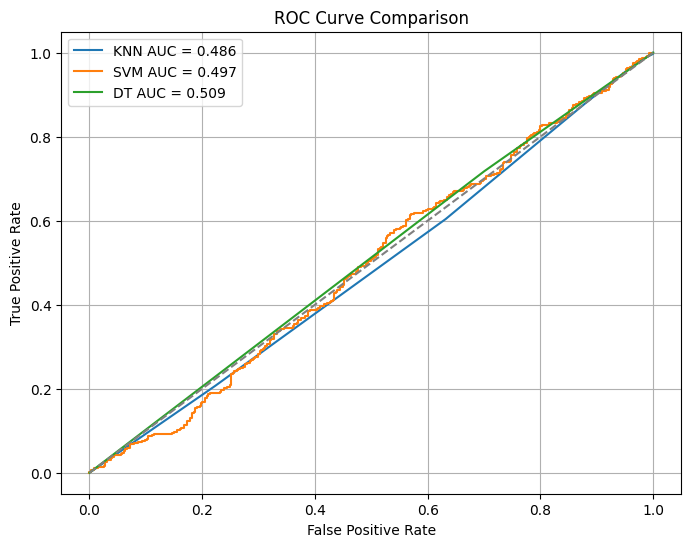

In [52]:
plt.figure(figsize=(8,6))

plt.plot(
    knn_fpr,
    knn_tpr,
    label=f"KNN AUC = {knn_auc:.3f}"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM AUC = {svm_auc:.3f}"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"DT AUC = {dt_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [53]:
svm_balanced = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

In [54]:
svm_balanced.fit(
    X_train_scaled,
    y_train
)

SVC(class_weight='balanced', probability=True, random_state=42)

In [55]:
svm_balanced_pred = svm_balanced.predict(
    X_test_scaled
)

In [56]:
evaluate_model(
    "Balanced SVM",
    y_test,
    svm_balanced_pred
)


Balanced SVM
Accuracy: 0.554
Precision: 0.7543655413271245
Recall: 0.5858951175406871
F1 Score: 0.6595419847328244


In [57]:
cm_balanced = confusion_matrix(
    y_test,
    svm_balanced_pred
)

cm_balanced

array([[183, 211],
       [458, 648]])

In [58]:
svm_balanced_probs = svm_balanced.predict_proba(
    X_test_scaled
)[:,1]

In [59]:
balanced_fpr, balanced_tpr, _ = roc_curve(
    y_test,
    svm_balanced_probs
)

balanced_auc = auc(
    balanced_fpr,
    balanced_tpr
)

print("Balanced SVM AUC:",
      balanced_auc)

Balanced SVM AUC: 0.5491206249254184


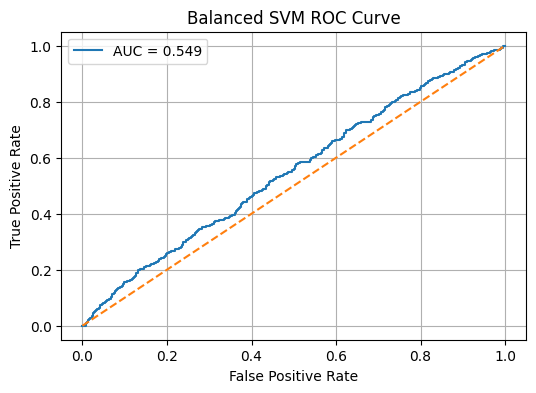

In [60]:
plt.figure(figsize=(6,4))

plt.plot(
    balanced_fpr,
    balanced_tpr,
    label=f"AUC = {balanced_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Balanced SVM ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [61]:
!pip install imbalanced-learn

In [62]:
from imblearn.over_sampling import SMOTE

In [63]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [64]:
pd.Series(y_train_smote).value_counts()

selected
1    5162
0    5162
Name: count, dtype: int64

In [65]:
svm_smote = SVC(
    probability=True,
    random_state=42
)

svm_smote.fit(
    X_train_smote,
    y_train_smote
)

SVC(probability=True, random_state=42)

In [66]:
svm_smote_pred = svm_smote.predict(
    X_test_scaled
)

In [67]:
svm_smote_probs = svm_smote.predict_proba(
    X_test_scaled
)[:,1]

In [68]:
fpr, tpr, _ = roc_curve(
    y_test,
    svm_smote_probs
)

smote_auc = auc(
    fpr,
    tpr
)

print("SMOTE SVM AUC:",
      smote_auc)

SMOTE SVM AUC: 0.5345427800369007


In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
rf_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=12
)

rf_200 = RandomForestClassifier(
    n_estimators=200,
    random_state=12
)

rf_300 = RandomForestClassifier(
    n_estimators=300,
    random_state=12
)

In [71]:
rf_100.fit(X_train_scaled, y_train)
rf_200.fit(X_train_scaled, y_train)
rf_300.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=300, random_state=12)

In [72]:
rf_100_pred = rf_100.predict(X_test_scaled)
rf_200_pred = rf_200.predict(X_test_scaled)
rf_300_pred = rf_300.predict(X_test_scaled)

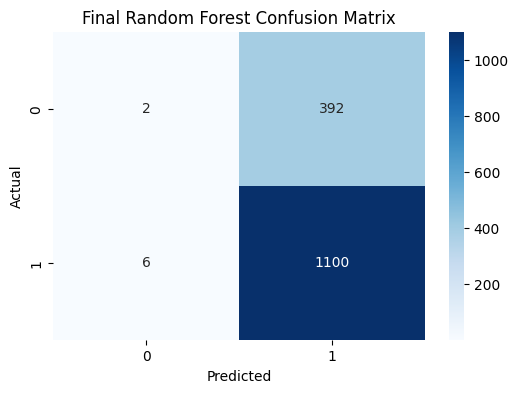

In [73]:
from sklearn.metrics import confusion_matrix

rf_final_pred = rf_200.predict(X_test_scaled)

cm_final = confusion_matrix(
    y_test,
    rf_final_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest Confusion Matrix")

plt.savefig("rf_confusion_matrix.png", bbox_inches="tight", dpi=300)

plt.show()

In [74]:
evaluate_model("Random Forest 100 Trees", y_test, rf_100_pred)
evaluate_model("Random Forest 200 Trees", y_test, rf_200_pred)
evaluate_model("Random Forest 300 Trees", y_test, rf_300_pred)


Random Forest 100 Trees
Accuracy: 0.7326666666666667
Precision: 0.7370544720914594
Recall: 0.9909584086799277
F1 Score: 0.8453528731199383

Random Forest 200 Trees
Accuracy: 0.7346666666666667
Precision: 0.7372654155495979
Recall: 0.9945750452079566
F1 Score: 0.8468052347959969

Random Forest 300 Trees
Accuracy: 0.736
Precision: 0.7372994652406417
Recall: 0.9972875226039783
F1 Score: 0.8478093774019985


In [75]:
rf_100_probs = rf_100.predict_proba(X_test_scaled)[:, 1]
rf_200_probs = rf_200.predict_proba(X_test_scaled)[:, 1]
rf_300_probs = rf_300.predict_proba(X_test_scaled)[:, 1]

In [76]:
rf_100_fpr, rf_100_tpr, _ = roc_curve(y_test, rf_100_probs)
rf_200_fpr, rf_200_tpr, _ = roc_curve(y_test, rf_200_probs)
rf_300_fpr, rf_300_tpr, _ = roc_curve(y_test, rf_300_probs)

rf_100_auc = auc(rf_100_fpr, rf_100_tpr)
rf_200_auc = auc(rf_200_fpr, rf_200_tpr)
rf_300_auc = auc(rf_300_fpr, rf_300_tpr)

print("RF 100 AUC:", rf_100_auc)
print("RF 200 AUC:", rf_200_auc)
print("RF 300 AUC:", rf_300_auc)

RF 100 AUC: 0.557657355816451
RF 200 AUC: 0.5626864541357249
RF 300 AUC: 0.5615746137817718


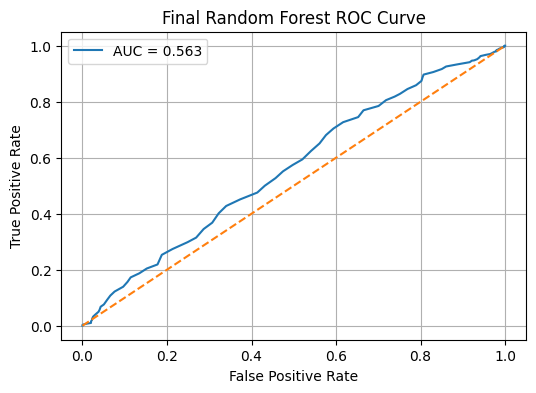

In [77]:
rf_final_probs = rf_200.predict_proba(X_test_scaled)[:, 1]

rf_final_fpr, rf_final_tpr, _ = roc_curve(
    y_test,
    rf_final_probs
)

rf_final_auc = auc(
    rf_final_fpr,
    rf_final_tpr
)

plt.figure(figsize=(6,4))

plt.plot(
    rf_final_fpr,
    rf_final_tpr,
    label=f"AUC = {rf_final_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Random Forest ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("rf_roc_curve.png", bbox_inches="tight", dpi=300)

plt.show()

In [78]:
rf_comparison = pd.DataFrame({
    "Model": ["RF 100", "RF 200", "RF 300"],
    "AUC": [rf_100_auc, rf_200_auc, rf_300_auc]
})

rf_comparison

,Model,AUC
0,RF 100,0.557657
1,RF 200,0.562686
2,RF 300,0.561575


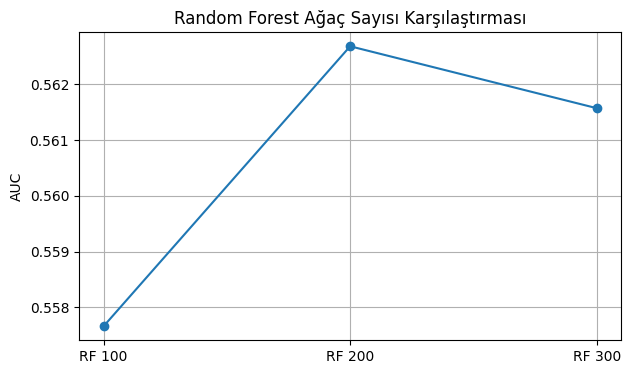

In [79]:
plt.figure(figsize=(7,4))

plt.plot(
    rf_comparison["Model"],
    rf_comparison["AUC"],
    marker="o"
)

plt.title("Random Forest Ağaç Sayısı Karşılaştırması")
plt.ylabel("AUC")
plt.grid(True)

plt.show()

In [80]:
importance_rf = pd.DataFrame({
    "Feature": X_final.columns,
    "Importance": rf_200.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf

,Feature,Importance
0,CGPA,0.150150
11,consistency_score,0.084134
8,github_score,0.083472
6,resume_score,0.083196
4,communication_score,0.082422
9,soft_skills_score,0.082394
5,coding_test_score,0.080930
1,skills_score,0.078233
10,interview_score,0.077899
2,projects_count,0.063012


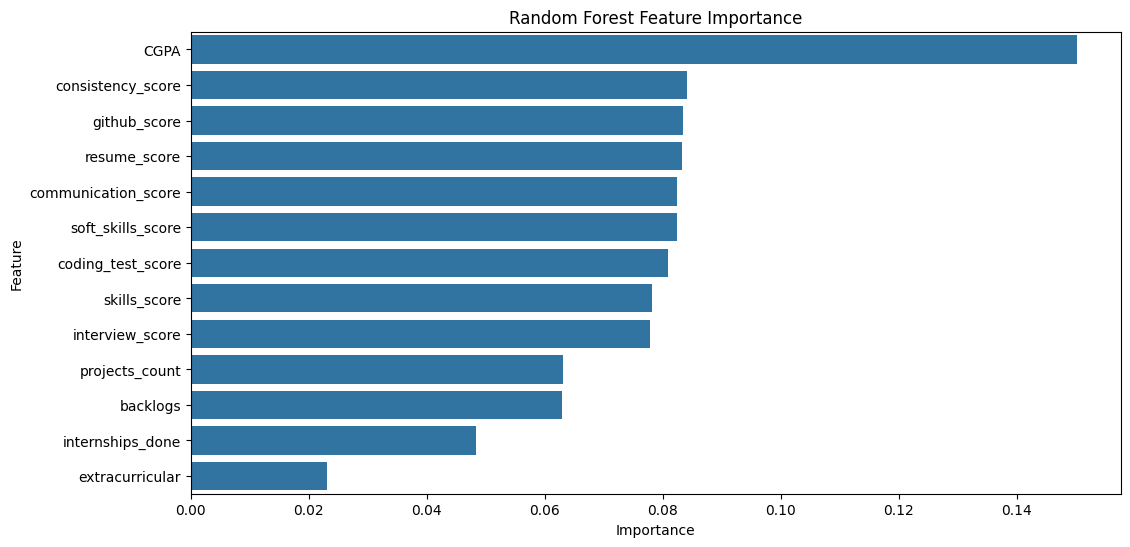

In [81]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance_rf,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.savefig("rf_feature_importance.png", bbox_inches="tight", dpi=300)

plt.show()

In [82]:
rf_scores = rf_200.predict_proba(
    X_test_scaled
)[:,1]

In [83]:
rf_scores_percent = rf_scores * 100

In [84]:
rf_predictions = rf_200.predict(
    X_test_scaled
)

In [85]:
final_results = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": rf_predictions,
    "Suitability Score": rf_scores_percent
})

final_results.head(10)

,Actual,Prediction,Suitability Score
0,1,1,70.0
1,1,1,81.0
2,1,1,67.0
3,1,1,81.0
4,0,1,64.0
5,1,1,79.5
6,1,1,87.0
7,1,1,53.0
8,1,1,69.5
9,0,1,62.5


In [86]:
rf_final_pred = rf_200.predict(X_test_scaled)

cm_final = confusion_matrix(
    y_test,
    rf_final_pred
)

cm_final

array([[   2,  392],
       [   6, 1100]])

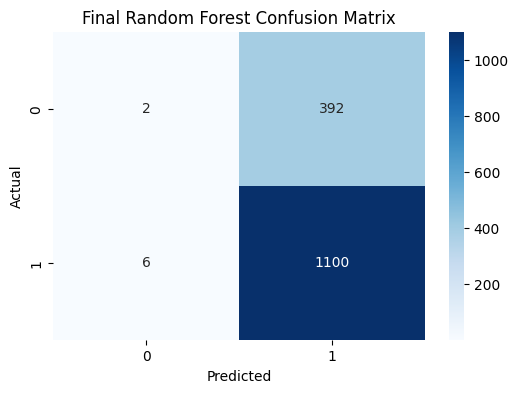

In [87]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Final Random Forest Confusion Matrix")

plt.savefig(
    "rf_confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

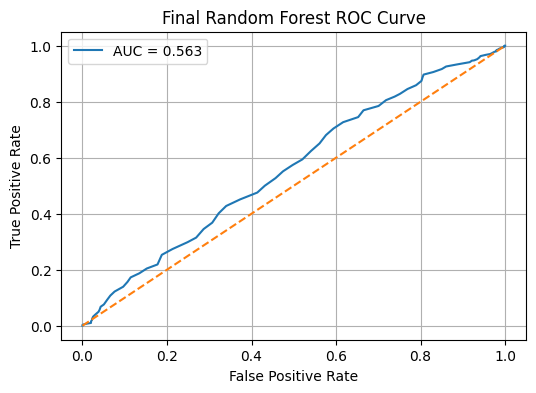

In [88]:
plt.figure(figsize=(6,4))

plt.plot(
    rf_final_fpr,
    rf_final_tpr,
    label=f"AUC = {rf_final_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Final Random Forest ROC Curve")

plt.legend()

plt.grid(True)

plt.savefig(
    "rf_roc_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [89]:
threshold = 70

In [90]:
custom_predictions = (
    rf_scores_percent >= threshold
).astype(int)

In [91]:
threshold_df = pd.DataFrame({
    "Score": rf_scores_percent,
    "Prediction": custom_predictions
})

threshold_df.head(10)

,Score,Prediction
0,70.0,1
1,81.0,1
2,67.0,0
3,81.0,1
4,64.0,0
5,79.5,1
6,87.0,1
7,53.0,0
8,69.5,0
9,62.5,0


In [92]:
!pip install shap

In [93]:
import shap

In [94]:
rf_200

RandomForestClassifier(n_estimators=200, random_state=12)

In [95]:
explainer = shap.TreeExplainer(rf_200)

In [96]:
shap_values = explainer.shap_values(X_test_scaled)

In [97]:
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_final.columns
)

In [98]:
print("shap_values shape:", shap_values.shape)
print("X_test_scaled_df shape:", X_test_scaled_df.shape)

shap_values shape: (1500, 13, 2)
X_test_scaled_df shape: (1500, 13)


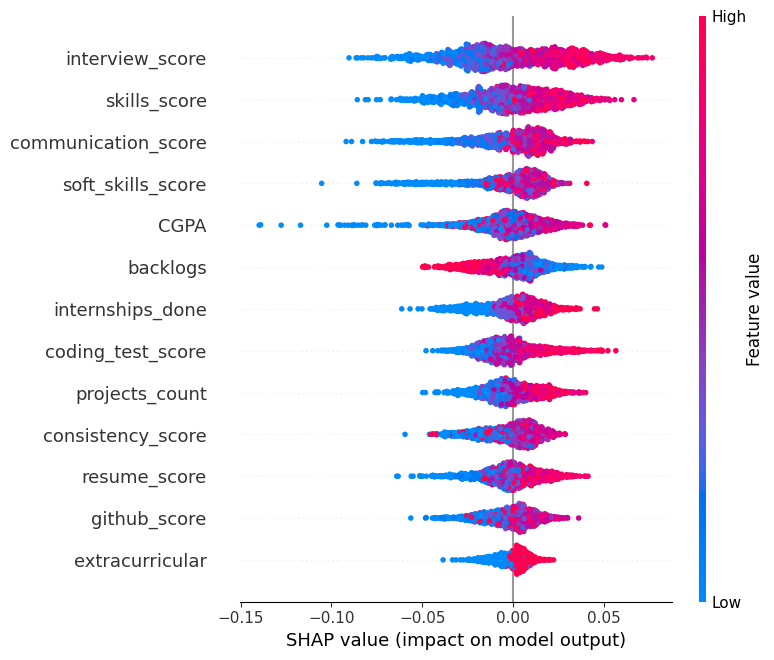

In [99]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled_df,
    show=False
)

plt.savefig(
    "shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

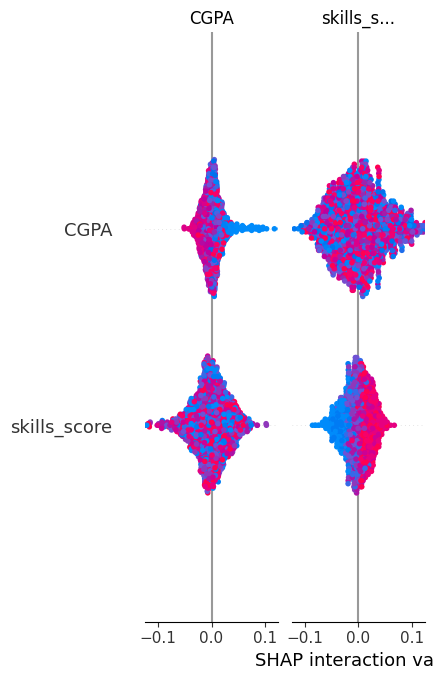

In [100]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df
)

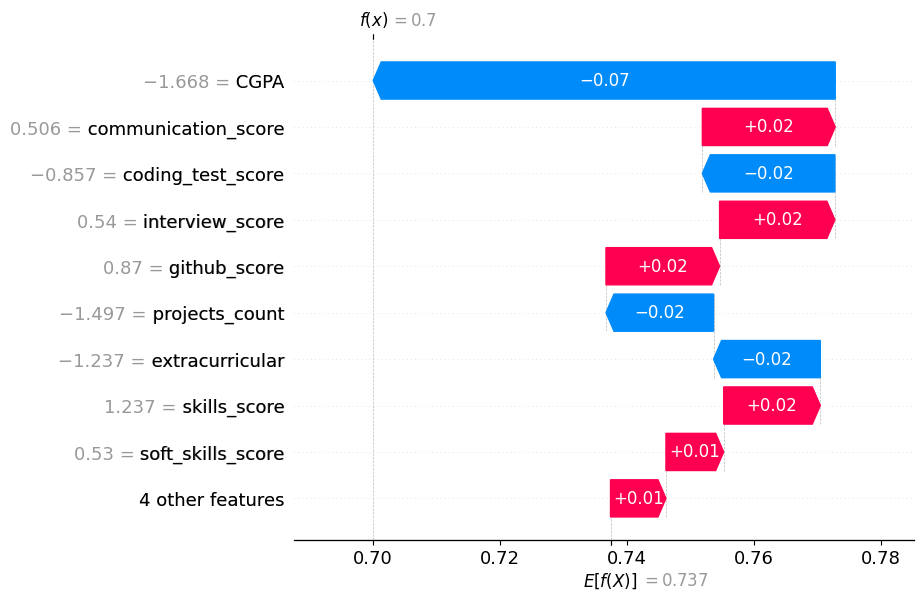

In [101]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_scaled_df.iloc[0],
        feature_names=X_test_scaled_df.columns
    ),
    show=False
)

plt.savefig("shap_waterfall.png", bbox_inches="tight", dpi=300)

plt.show()

In [102]:
import pickle
import os

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_200, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("features.pkl", "wb") as f:
    pickle.dump(list(X_final.columns), f)

print("Dosyalar kaydedildi:")
print(os.listdir())

Dosyalar kaydedildi:
['heatmap.png', 'rf_confusion_matrix.png', 'rf_model.pkl', 'shap_waterfall.png', 'shap_summary.png', 'feature_selection_comparison.png', 'scaler.pkl', 'rf_feature_importance.png', '__notebook__.ipynb', 'features.pkl', 'rf_roc_curve.png']


In [103]:
import joblib

joblib.dump(rf_200, "rf_model.joblib", compress=3)

['rf_model.joblib']

In [104]:
import os

print(os.path.getsize("rf_model.joblib") / 1024 / 1024)

7.775054931640625
